## Importar librerias

In [1]:
import pandas as pd

In [2]:
# Carga de datos
application_train = pd.read_csv("../Data/raw/application_train.csv")
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## EDA

In [3]:
# shape del dataset
application_train.shape

(307511, 122)

In [4]:
application_train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            str    
 3    CODE_GENDER                   str    
 4    FLAG_OWN_CAR                  str    
 5    FLAG_OWN_REALTY               str    
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               str    
 12   NAME_INCOME_TYPE              str    
 13   NAME_EDUCATION_TYPE           str    
 14   NAME_FAMILY_STATUS            str    
 15   NAME_HOUSING_TYPE             str    
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EMPLOYED

In [5]:
# Conteo de valores nulos en total
nulls = application_train.isnull().sum()

# Porcentaje de valores nulos por columna
nulls_pct = (nulls / len(application_train) * 100).round(2)

# Guardamos un reporte de los valores nulos por columna
null_report = (pd.DataFrame({'nulos': nulls, 'porcentaje': nulls_pct})).query('nulos > 0').sort_values('porcentaje',ascending=False)

null_report

,nulos,porcentaje
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


In [6]:
null_report[null_report['porcentaje'] > 40]

,nulos,porcentaje
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


In [7]:
# Analisis de TARGET
target_counts = application_train['TARGET'].value_counts()
target_pct = application_train['TARGET'].value_counts(normalize=True) * 100

print('Conteo de observaciones en TARGET\n', target_counts)
print('\nPorcentaje de cada valor\n', target_pct.round(2))

Conteo de observaciones en TARGET
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Porcentaje de cada valor
 TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


/tmp/ipykernel_1775/57334752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=application_train, ax=ax, palette='deep')


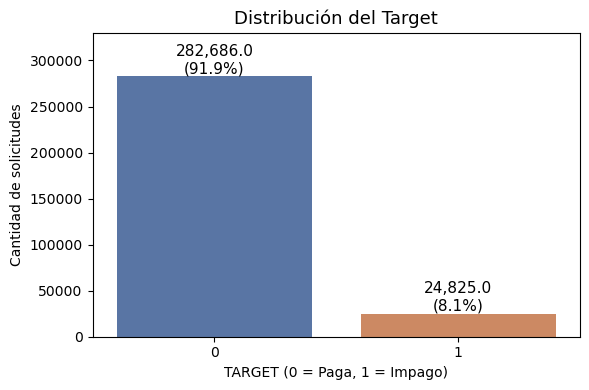

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6,4))

sns.countplot(x='TARGET', data=application_train, ax=ax, palette='deep')

ax.set_title('Distribución del Target', fontsize=13)
ax.set_xlabel('TARGET (0 = Paga, 1 = Impago)')
ax.set_ylabel('Cantidad de solicitudes')
ax.set_ylim(0, 330000)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(application_train)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom', fontsize=11)
    
plt.tight_layout()
plt.savefig('../Reports/figures/01_target_distribution.png', dpi=150)
plt.show()

In [9]:
# Análisis de variables numéricas
application_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


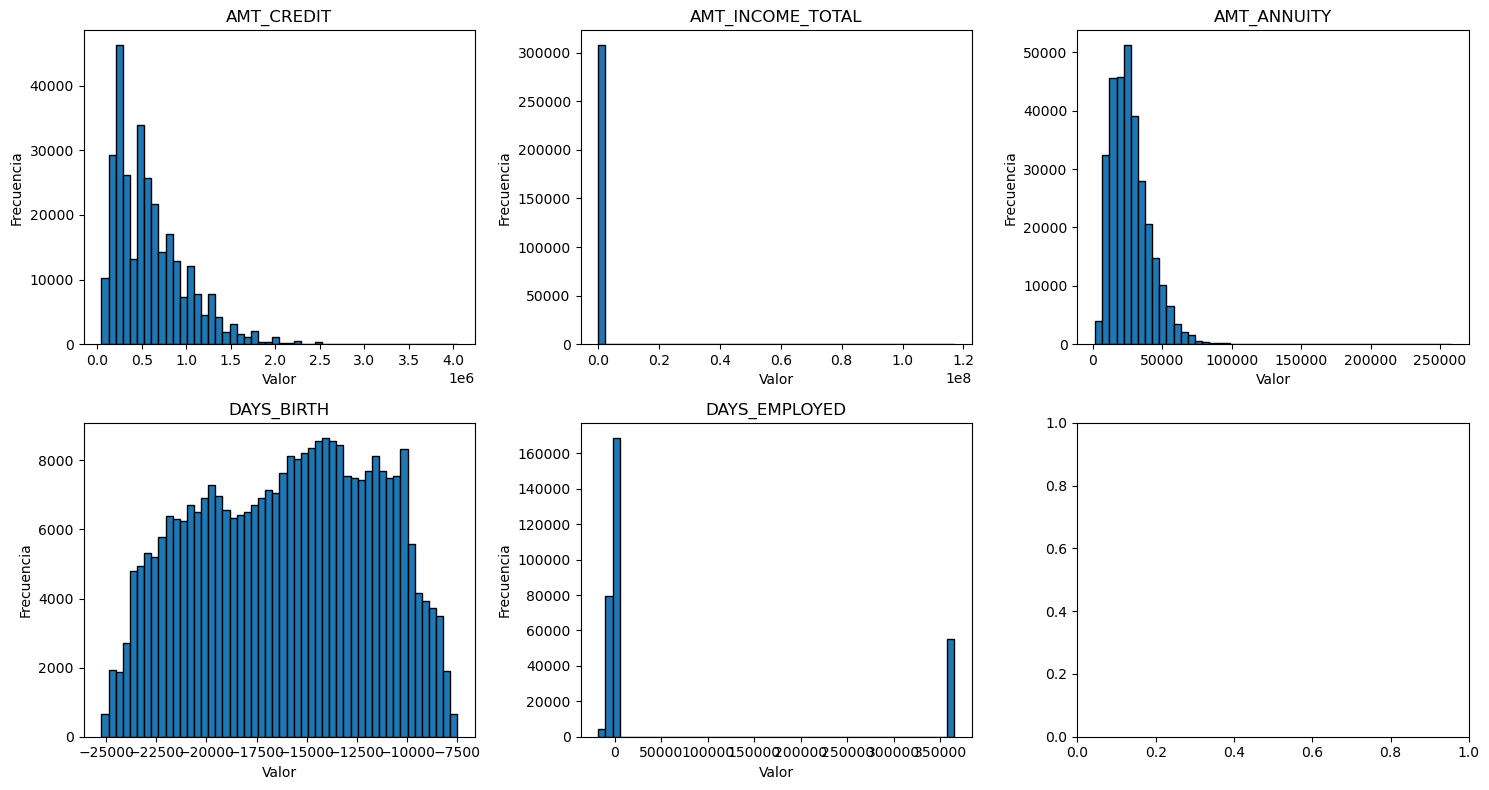

In [10]:
cols_interes = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_interes):
    axes[i].hist(application_train[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    
plt.tight_layout()
plt.savefig('../Reports/figures/02_numeric_distributions.png')
plt.show()

In [11]:
# Analisis de valores anomalos en DAYS_EMPLOYED
application_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [12]:
application_train['DAYS_EMPLOYED'].max()

np.int64(365243)

In [13]:
# Total de observaciones con valor maximo
total_cod = (application_train['DAYS_EMPLOYED'] == 365243).sum()
total_cod

np.int64(55374)

In [14]:
# Porcentaje de observaciones con valor maximo
cod_report = (total_cod / len(application_train) * 100).round(2)
print(cod_report)

18.01


In [15]:
# Analisis de AMT_INCOME_TOTAL
application_train['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [16]:
# Cantidad de clientes con ingresos por encima de un umbral
print(f'Clientes con ingresos mayores a 1 millón: {(application_train['AMT_INCOME_TOTAL'] > 1_000_000).sum()}\n')
print(f'Clientes con ingresos mayores a 10 millones: {(application_train['AMT_INCOME_TOTAL'] > 10_000_000).sum()}\n')

Clientes con ingresos mayores a 1 millón: 250

Clientes con ingresos mayores a 10 millones: 3



In [17]:
# Analisis de variables categoricas
cat_cols = application_train.select_dtypes(include='str').columns.tolist()
print(cat_cols)
print(f'\nTotal: {len(cat_cols)} variables categóricas')

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Total: 16 variables categóricas


In [18]:
# Valores unicos en cara variable
for col in cat_cols:
    print(f"{col}: {application_train[col].nunique()} valores únicos")

NAME_CONTRACT_TYPE: 2 valores únicos
CODE_GENDER: 3 valores únicos
FLAG_OWN_CAR: 2 valores únicos
FLAG_OWN_REALTY: 2 valores únicos
NAME_TYPE_SUITE: 7 valores únicos
NAME_INCOME_TYPE: 8 valores únicos
NAME_EDUCATION_TYPE: 5 valores únicos
NAME_FAMILY_STATUS: 6 valores únicos
NAME_HOUSING_TYPE: 6 valores únicos
OCCUPATION_TYPE: 18 valores únicos
WEEKDAY_APPR_PROCESS_START: 7 valores únicos
ORGANIZATION_TYPE: 58 valores únicos
FONDKAPREMONT_MODE: 4 valores únicos
HOUSETYPE_MODE: 3 valores únicos
WALLSMATERIAL_MODE: 7 valores únicos
EMERGENCYSTATE_MODE: 2 valores únicos


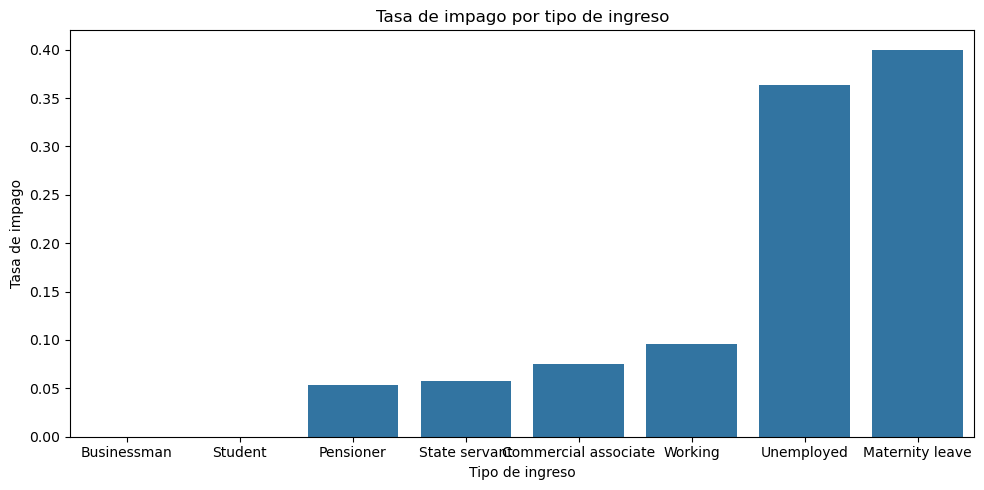

In [19]:
# Relacion entre categoricas y el target
fig, ax = plt.subplots(figsize=(10,5))

tasa_impago = (
    application_train.groupby('NAME_INCOME_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

sns.barplot(data=tasa_impago, x='NAME_INCOME_TYPE', y='TARGET', ax=ax)

ax.set_title('Tasa de impago por tipo de ingreso')
ax.set_xlabel('Tipo de ingreso')
ax.set_ylabel('Tasa de impago')

plt.tight_layout()
plt.savefig('../Reports/figures/03_impago_por_tipo_ingreso.png')
plt.show()

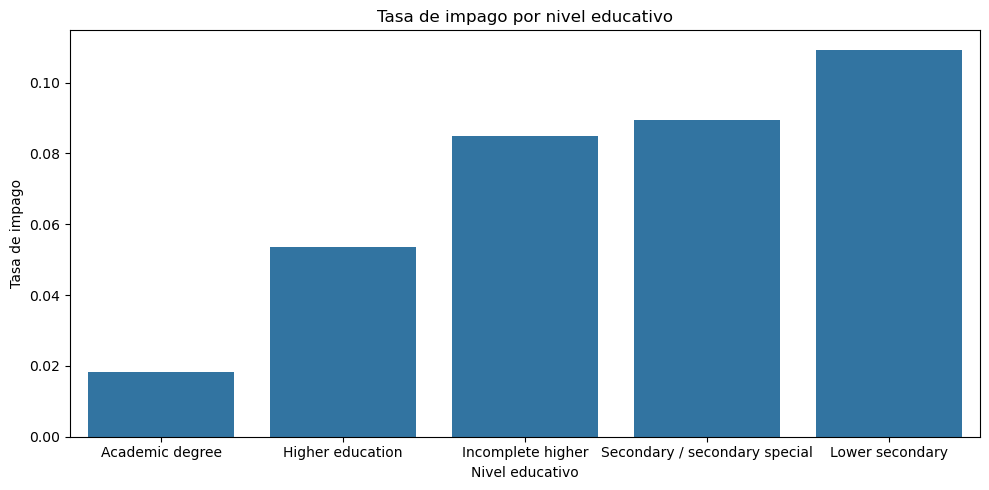

In [20]:
fig, ax = plt.subplots(figsize=(10,5))

tasa_impago = (
    application_train.groupby('NAME_EDUCATION_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

sns.barplot(data=tasa_impago, x='NAME_EDUCATION_TYPE', y='TARGET', ax=ax)

ax.set_title('Tasa de impago por nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Tasa de impago')

plt.tight_layout()
plt.savefig('../Reports/figures/04_impago_por_nivel_educativo.png')
plt.show()

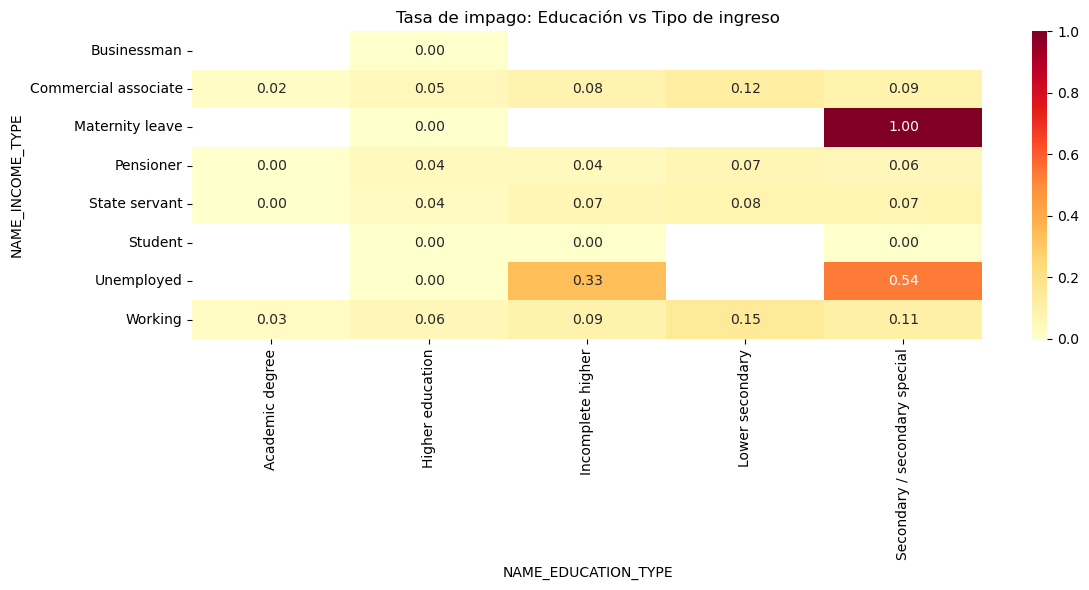

In [21]:
fig, ax = plt.subplots(figsize=(12,6))

cross = (application_train.groupby(['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'])['TARGET']
         .mean()
         .unstack())

sns.heatmap(cross, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)

ax.set_title('Tasa de impago: Educación vs Tipo de ingreso')
plt.tight_layout()
plt.savefig('../Reports/figures/04_impago_educacion_vs_ingreso.png')
plt.show()

In [27]:
import duckdb

con = duckdb.connect()

con.execute("CREATE VIEW application AS SELECT * FROM application_train")

result = con.execute("SELECT COUNT(*) AS total_registros FROM application").fetchdf()
print(result)

   total_registros
0           307511
